In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from itertools import combinations_with_replacement 

In [2]:
df = pd.read_csv('./dataset/customer_churn.csv')
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5710,6297-NOOPG,Female,0,Yes,No,70,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,110.50,7752.05,No
1060,6100-FJZDG,Male,0,Yes,Yes,26,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),20.05,505.9,No
1220,0872-JCPIB,Male,0,No,No,17,Yes,Yes,DSL,Yes,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),65.75,1111.2,No
988,9046-JBFWA,Male,0,No,Yes,27,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.15,537.35,No
5291,1334-PDUKM,Female,0,Yes,No,68,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,One year,No,Credit card (automatic),86.45,5762.95,No
6234,5995-LFTLE,Male,0,No,No,58,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.30,1474.35,No
5371,0877-SDMBN,Female,0,No,No,54,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.95,5639.05,Yes
5821,9066-QRSDU,Female,0,Yes,No,69,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,26.30,1763.55,No
5244,6233-HXJMX,Female,0,No,No,45,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),89.30,4192.15,No
385,4895-TMWIR,Male,1,Yes,No,11,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.95,214.75,Yes


In [25]:
def print_detail(path):
    with open(path, 'r') as files:
        for file in files:
            print(file.strip())

In [3]:
pd.set_option('display.max_columns', len(df.columns))

In [4]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6506,5889-LFOLL,Female,0,No,No,13,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.60,1115.2,Yes
2055,1216-BGTSP,Male,0,No,No,45,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),108.45,4964.7,No
5991,8063-RJYNF,Male,0,No,No,16,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.25,1483.25,Yes
574,6030-REHUX,Female,1,Yes,No,28,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,110.85,3204.4,No
1900,0754-EEBDC,Male,0,Yes,Yes,4,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.90,76.65,No
494,6579-JPICP,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,20.4,No
588,0742-LAFQK,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,No,Yes,Two year,Yes,Electronic check,99.15,7422.1,No
2874,8347-GDTMP,Female,0,Yes,No,64,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.45,1225.65,No
5115,6374-AFWOX,Male,0,Yes,No,46,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Mailed check,65.65,3047.15,No
6217,1599-MMYRQ,Male,0,Yes,Yes,62,Yes,No,Fiber optic,Yes,Yes,No,No,No,No,One year,Yes,Credit card (automatic),81.45,4983.05,No


In [5]:
df.drop('customerID', axis='columns', inplace=True)

In [6]:
df.shape

(7043, 20)

In [7]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
numerik_df = df[df.describe().columns]
kategori_df = df.drop(columns=df.describe().columns)

display(kategori_df.sample(10))
display(numerik_df.sample(10))

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
2541,Female,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),3952.45,No
5962,Male,Yes,No,Yes,No,Fiber optic,Yes,Yes,No,No,No,No,Month-to-month,No,Bank transfer (automatic),1321.3,No
1507,Male,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),1008.7,No
101,Female,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.45,No
5091,Male,No,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),208.7,Yes
5951,Female,No,No,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,No,Credit card (automatic),3541.4,No
5061,Female,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,No,One year,No,Electronic check,4154.55,No
4663,Female,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,321.75,Yes
2951,Male,Yes,No,Yes,No,DSL,Yes,No,No,Yes,No,Yes,One year,Yes,Mailed check,1274.45,No
5800,Female,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Bank transfer (automatic),1345.65,No


,SeniorCitizen,tenure,MonthlyCharges
230,0,54,108.00
5414,0,64,105.65
6504,0,3,79.25
6140,0,3,19.95
3449,0,52,95.70
131,0,25,58.60
375,0,43,85.10
6421,0,21,71.05
3257,0,22,93.20
1713,0,52,61.35


In [9]:
def table_diagnose(df):
    new_df = df.copy(deep=True)
    _1 = pd.concat([new_df.isnull().sum(), new_df.nunique(), new_df.dtypes], axis=1, keys=['n null', 'n unique', 'types']).reset_index()

    _2 = new_df.nunique().reset_index()
    _3 = _2.loc[_2[0] < 5, 'index'].apply(lambda x: new_df[x].unique())

    result = pd.merge(_1, _3, left_index=True, right_index=True, how='outer')
    result.rename(columns={'index_x': 'columns', 'index_y':'unique vals'}, inplace=True)
    return result

table_diagnose(df)

,columns,n null,n unique,types,unique vals
0,gender,0,2,object,"[Female, Male]"
1,SeniorCitizen,0,2,int64,"[0, 1]"
2,Partner,0,2,object,"[Yes, No]"
3,Dependents,0,2,object,"[No, Yes]"
4,tenure,0,73,int64,NaN
5,PhoneService,0,2,object,"[No, Yes]"
6,MultipleLines,0,3,object,"[No phone service, No, Yes]"
7,InternetService,0,3,object,"[DSL, Fiber optic, No]"
8,OnlineSecurity,0,3,object,"[No, Yes, No internet service]"
9,OnlineBackup,0,3,object,"[Yes, No, No internet service]"


In [43]:
# df['TotalCharges'] = df['TotalCharges'].astype(float) # jika di run akan error karna ada karakter yang bukan angka, sehingga tidak bisa dilakukan casting

In [10]:
import re
# df['TotalCharges'].apply(lambda x: re.findall(r'^\d+\.?\d+$', x))

arr = []
for idx, val in enumerate(df['TotalCharges'].values):
    if re.search(r'^\D*$', val):
        arr.append((idx, val))

print(arr)

[(488, ' '), (753, ' '), (936, ' '), (1082, ' '), (1340, ' '), (3331, ' '), (3826, ' '), (4380, ' '), (5218, ' '), (6670, ' '), (6754, ' ')]


In [15]:
df.loc[pd.DataFrame(arr)[0], 'TotalCharges']

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object

In [12]:
dummy_df =df.copy(deep=True)

dummy_df['TotalCharges'].replace({' ': np.nan}, inplace=True)
dummy_df['TotalCharges'] = dummy_df['TotalCharges'].astype(float)

In [13]:
table_diagnose(dummy_df)

,columns,n null,n unique,types,unique vals
0,gender,0,2,object,"[Female, Male]"
1,SeniorCitizen,0,2,int64,"[0, 1]"
2,Partner,0,2,object,"[Yes, No]"
3,Dependents,0,2,object,"[No, Yes]"
4,tenure,0,73,int64,NaN
5,PhoneService,0,2,object,"[No, Yes]"
6,MultipleLines,0,3,object,"[No phone service, No, Yes]"
7,InternetService,0,3,object,"[DSL, Fiber optic, No]"
8,OnlineSecurity,0,3,object,"[No, Yes, No internet service]"
9,OnlineBackup,0,3,object,"[Yes, No, No internet service]"


In [16]:
dummy_df.loc[pd.DataFrame(arr)[0], 'TotalCharges']

488    NaN
753    NaN
936    NaN
1082   NaN
1340   NaN
3331   NaN
3826   NaN
4380   NaN
5218   NaN
6670   NaN
6754   NaN
Name: TotalCharges, dtype: float64

In [18]:
dummy_df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4954,Male,0,No,Yes,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,90.85,90.85,Yes
1611,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),90.95,6468.60,No
4361,Male,0,No,No,29,Yes,No,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.20,No
4276,Female,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,49.60,114.70,Yes
5830,Male,0,No,Yes,30,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),25.35,723.30,No
2926,Female,0,Yes,No,69,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,116.00,8182.85,No
6215,Female,1,No,No,6,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.25,560.60,Yes
2921,Male,0,No,No,9,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.50,829.10,Yes
4931,Male,0,Yes,No,15,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,103.45,1539.80,No
5231,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.75,1587.55,Yes


In [19]:
dummy_df.replace({'No phone service': 'No', 'No internet service': 'No'}, inplace=True)

In [20]:
table_diagnose(dummy_df)

,columns,n null,n unique,types,unique vals
0,gender,0,2,object,"[Female, Male]"
1,SeniorCitizen,0,2,int64,"[0, 1]"
2,Partner,0,2,object,"[Yes, No]"
3,Dependents,0,2,object,"[No, Yes]"
4,tenure,0,73,int64,NaN
5,PhoneService,0,2,object,"[No, Yes]"
6,MultipleLines,0,2,object,"[No, Yes]"
7,InternetService,0,3,object,"[DSL, Fiber optic, No]"
8,OnlineSecurity,0,2,object,"[No, Yes]"
9,OnlineBackup,0,2,object,"[Yes, No]"


In [26]:
print_detail('./dataset/data_detail.txt')

# *DATA DETAIL*

Data churn pelanggan Telco berisi informasi tentang perusahaan telco fiktif yang menyediakan layanan telepon rumah dan Internet kepada 7043 pelanggan di California pada Q3. Ini menunjukkan pelanggan mana yang telah pergi, tinggal, atau mendaftar untuk layanan mereka. Beberapa demografi penting disertakan untuk setiap pelanggan, serta Skor Kepuasan, Skor Churn, dan indeks Nilai Seumur Hidup Pelanggan (CLTV).

* gender: gender dari customer Pria atau Wanita.
* SeniorCitizen: mengindikasikan bahwa customer 65 tahun atau lebih, jika 1 iya jika 0 tidak.
* Dependents: mengindikasikan bahwa customer hidup dengan beberapa dependent seperti anak, orang tua, kakek atau nenek, dan seterusnya.
* tenure: menunjukkan jumlah total bulan customer telah berlangganan pada akhir kuartal Q3.
* PhoneServices: menunjukkan jika customer berlangganan layanan telepon rumah dengan perusahaan: iya atau tidak.
* MultipleLines: menunjukkan jika customer berlangganan beberapa saluran telepon dengan

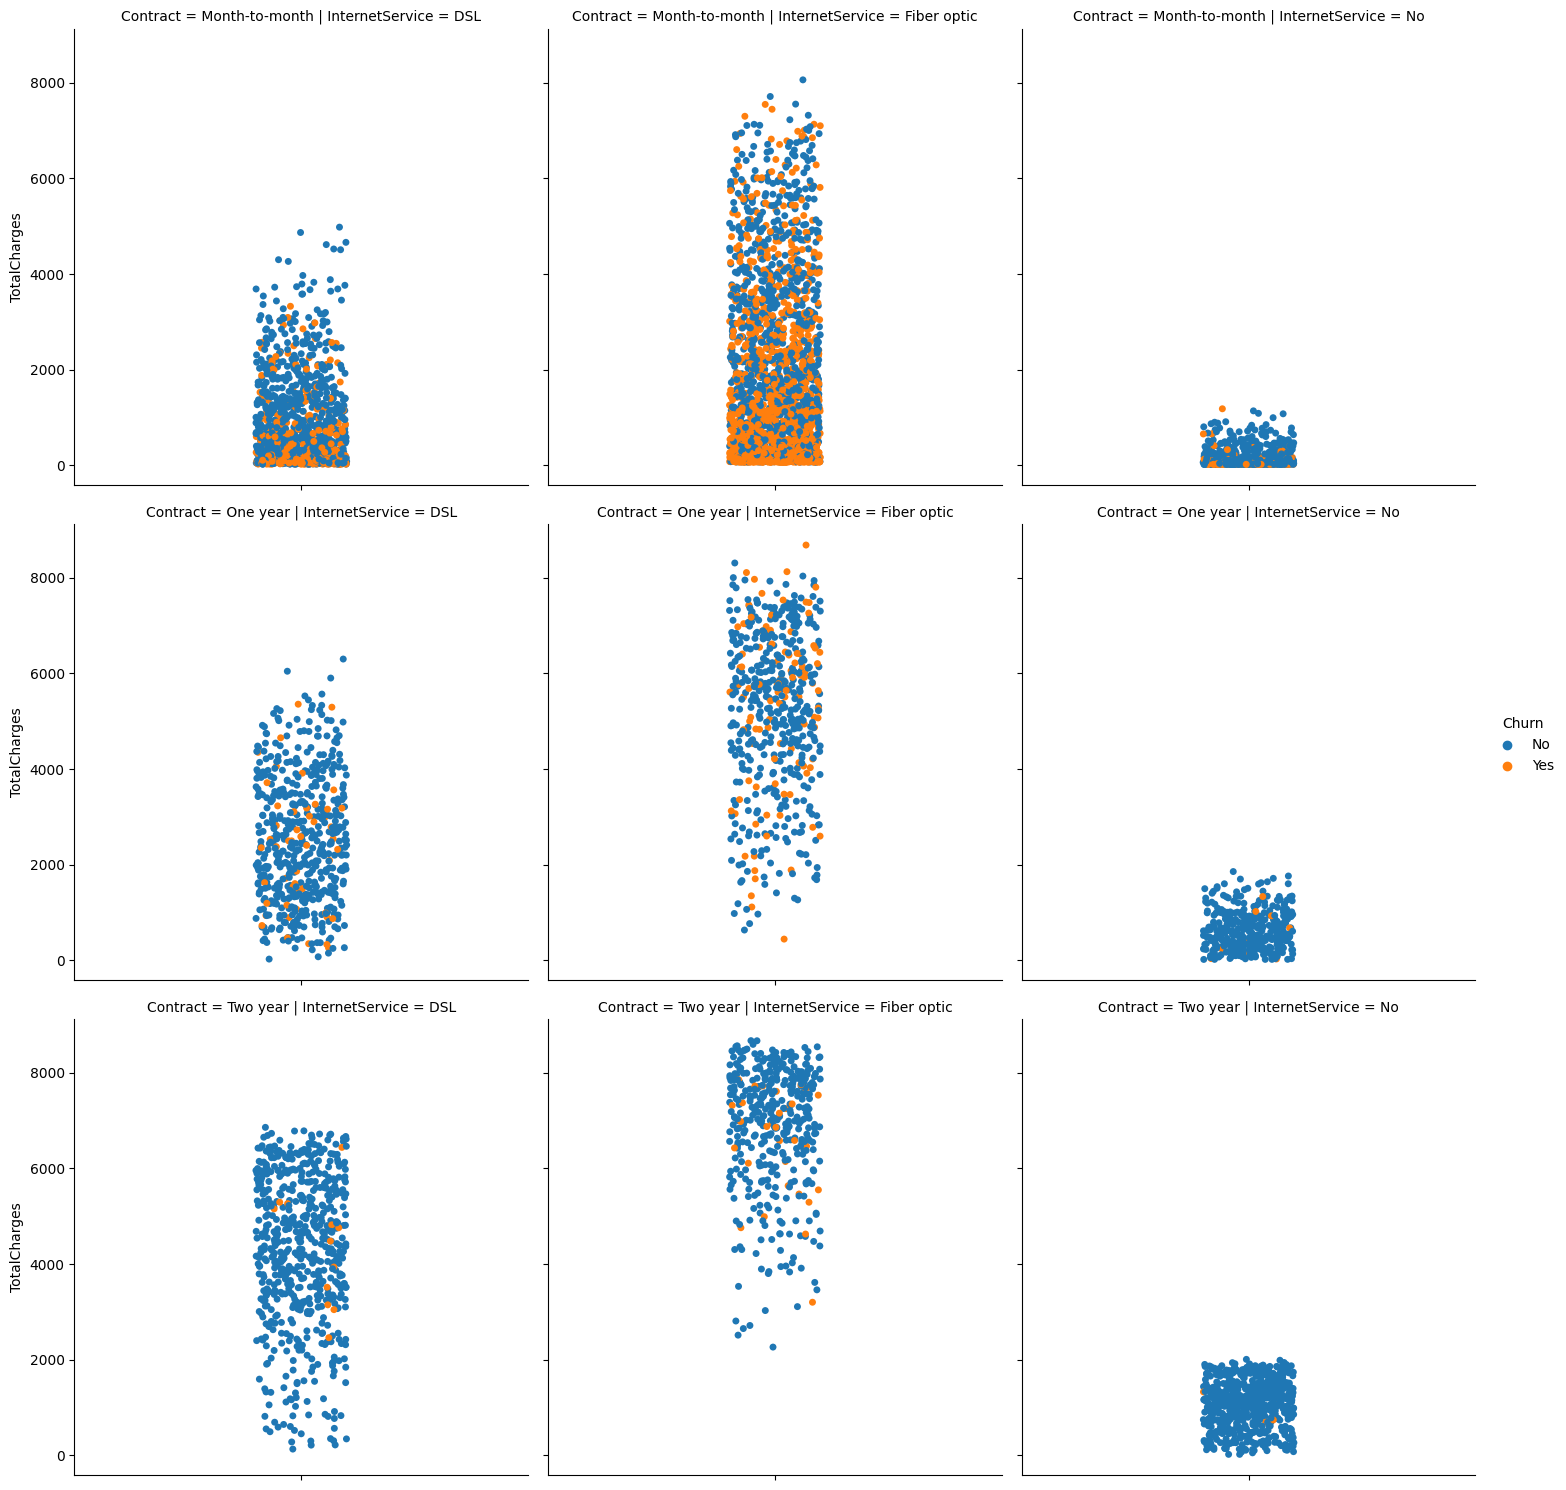

In [30]:
sns.catplot(data=dummy_df, y='TotalCharges', row='Contract', col='InternetService', hue='Churn')

In [14]:
df['gender'] = df['gender'].replace({'Female':1, 'Male':0})
df['gender']

0       1
1       0
2       0
3       0
4       1
       ..
7038    0
7039    1
7040    1
7041    0
7042    0
Name: gender, Length: 7043, dtype: int64

In [15]:
diagnose_data(df)

shape:
(7043, 20)

columns:
Churn
Contract
Dependents
DeviceProtection
InternetService
MonthlyCharges
MultipleLines
OnlineBackup
OnlineSecurity
PaperlessBilling
Partner
PaymentMethod
PhoneService
SeniorCitizen
StreamingMovies
StreamingTV
TechSupport
TotalCharges
gender
tenure

null values:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-nu

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [16]:
df = pd.get_dummies(data=df, columns=get_data_type(df, 'object').columns.values)

In [17]:
diagnose_data(df)

shape:
(7043, 27)

columns:
Churn
Contract_Month-to-month
Contract_One year
Contract_Two year
Dependents
DeviceProtection
InternetService_DSL
InternetService_Fiber optic
InternetService_No
MonthlyCharges
MultipleLines
OnlineBackup
OnlineSecurity
PaperlessBilling
Partner
PaymentMethod_Bank transfer (automatic)
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
PhoneService
SeniorCitizen
StreamingMovies
StreamingTV
TechSupport
TotalCharges
gender
tenure

null values:
gender                                      0
SeniorCitizen                               0
Partner                                     0
Dependents                                  0
tenure                                      0
PhoneService                                0
MultipleLines                               0
OnlineSecurity                              0
OnlineBackup                                0
DeviceProtection                            0
TechSupport              

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(missing_values=np.nan)

df['TotalCharges'] = imp.fit_transform(
    df[['TotalCharges']]
)

diagnose_data(df)

shape:
(7043, 27)

columns:
Churn
Contract_Month-to-month
Contract_One year
Contract_Two year
Dependents
DeviceProtection
InternetService_DSL
InternetService_Fiber optic
InternetService_No
MonthlyCharges
MultipleLines
OnlineBackup
OnlineSecurity
PaperlessBilling
Partner
PaymentMethod_Bank transfer (automatic)
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
PhoneService
SeniorCitizen
StreamingMovies
StreamingTV
TechSupport
TotalCharges
gender
tenure

null values:
gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                        

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [19]:
pd.set_option('display.max_columns', 27)
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2283.300441,0.265370,0.343746,0.439585,0.216669,0.550192,0.209144,0.240664,0.219225,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2265.000258,0.441561,0.474991,0.496372,0.412004,0.497510,0.406726,0.427517,0.413751,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,402.225000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1400.550000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
X = df.drop(columns=['Churn'], axis='columns')
y = df['Churn']

In [21]:
X.shape

(7043, 26)

In [22]:
y.shape

(7043,)

In [23]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=50)
outlierd = lof.fit_predict(X) == -1

In [24]:
list_outlier_idx = [i for i, val in enumerate(list(outlierd)) if val ==True] 
list_outlier_idx

[20,
 133,
 185,
 211,
 252,
 272,
 282,
 376,
 893,
 1144,
 1185,
 1282,
 1331,
 1334,
 1654,
 1694,
 1704,
 1730,
 2046,
 2208,
 2246,
 2295,
 2427,
 2462,
 2465,
 2993,
 2995,
 3009,
 3092,
 3185,
 3258,
 3357,
 3652,
 3756,
 3766,
 3773,
 3865,
 3983,
 4005,
 4262,
 4290,
 4396,
 4424,
 4459,
 4586,
 4607,
 4610,
 4641,
 4704,
 4725,
 4757,
 4767,
 4924,
 5186,
 5411,
 5519,
 5553,
 5678,
 5682,
 5950,
 5961,
 5987,
 6001,
 6074,
 6256,
 6482,
 6509,
 6536,
 6549,
 6607,
 6768,
 6979]

In [25]:
df.drop(index=list_outlier_idx, axis='index', inplace=True)

In [26]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000
mean,0.495481,0.162100,0.485583,0.299814,32.664467,0.908048,0.423756,0.288194,0.347152,0.345431,0.291780,0.386028,0.388753,0.592741,64.984206,2302.750230,0.261655,0.339263,0.442978,0.217759,0.546550,0.210730,0.242720,0.220485,0.217903,0.334098,0.227514
std,0.500015,0.368569,0.499828,0.458209,24.472496,0.288979,0.494188,0.452954,0.476099,0.475543,0.454614,0.486872,0.487502,0.491359,30.041528,2261.735465,0.439567,0.473493,0.496773,0.412752,0.497864,0.407856,0.428758,0.414603,0.412851,0.471708,0.419257
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.850000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.250000,419.375000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.500000,1421.900000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.900000,3825.025000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.650000,8594.400000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
diagnose_data(df)

shape:
(6971, 27)

columns:
Churn
Contract_Month-to-month
Contract_One year
Contract_Two year
Dependents
DeviceProtection
InternetService_DSL
InternetService_Fiber optic
InternetService_No
MonthlyCharges
MultipleLines
OnlineBackup
OnlineSecurity
PaperlessBilling
Partner
PaymentMethod_Bank transfer (automatic)
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
PhoneService
SeniorCitizen
StreamingMovies
StreamingTV
TechSupport
TotalCharges
gender
tenure

null values:
gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                        

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,0,1,0,1,0,0,0,0,1,0


In [28]:
cols_scale = [col for col in df.columns if len(df[col].unique()) > 2] 
cols_scale

['tenure', 'MonthlyCharges', 'TotalCharges']

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[cols_scale] = scaler.fit_transform(df[cols_scale])
df[cols_scale]

,tenure,MonthlyCharges,TotalCharges
0,0.013889,0.115538,0.001283
1,0.472222,0.385458,0.218138
2,0.027778,0.354582,0.010413
3,0.625000,0.239542,0.212453
4,0.027778,0.522410,0.015486
...,...,...,...
7038,0.333333,0.662849,0.229915
7039,1.000000,0.846116,0.856394
7040,0.152778,0.113048,0.038202
7041,0.055556,0.559263,0.033555


In [30]:
diagnose_data(df)

shape:
(6971, 27)

columns:
Churn
Contract_Month-to-month
Contract_One year
Contract_Two year
Dependents
DeviceProtection
InternetService_DSL
InternetService_Fiber optic
InternetService_No
MonthlyCharges
MultipleLines
OnlineBackup
OnlineSecurity
PaperlessBilling
Partner
PaymentMethod_Bank transfer (automatic)
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check
PhoneService
SeniorCitizen
StreamingMovies
StreamingTV
TechSupport
TotalCharges
gender
tenure

null values:
gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                        

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,0.013889,0,0,0,1,0,0,0,0,1,0.115538,0.001283,0,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,0.472222,1,0,1,0,1,0,0,0,0,0.385458,0.218138,0,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0.027778,1,0,1,1,0,0,0,0,1,0.354582,0.010413,1,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,0.625000,0,0,1,0,1,1,0,0,0,0.239542,0.212453,0,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,0.027778,1,0,0,0,0,0,0,0,1,0.522410,0.015486,1,0,1,0,1,0,0,0,0,1,0


In [31]:
df['Churn'].value_counts()

0    5147
1    1824
Name: Churn, dtype: int64

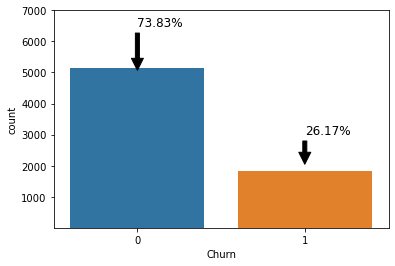

In [93]:
percent_minor = (df[df['Churn'] == 1]['Churn'].count()/df['Churn'].count())*100
percent_major = (df[df['Churn'] == 0]['Churn'].count()/df['Churn'].count())*100

ax = sns.countplot(x=df['Churn'])
ax.annotate(
    f'{round(percent_minor, 2)}%', 
    xy=(1, 2000), 
    xytext=(1, 3000), 
    fontsize=12,
    arrowprops=dict(facecolor='black', shrink=0.05)
)

ax.annotate(
    f'{round(percent_major, 2)}%', 
    xy=(0, 5000), 
    xytext=(0, 6500), 
    fontsize=12,
    arrowprops=dict(facecolor='black', shrink=0.05)
)

plt.yticks([1000, 2000, 3000, 4000, 5000, 6000, 7000])
plt.show()

In [34]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn'], axis='columns')
y = df['Churn']

smote = SMOTE(sampling_strategy='minority', random_state=101)

X_sm, y_sm = smote.fit_resample(X, y)

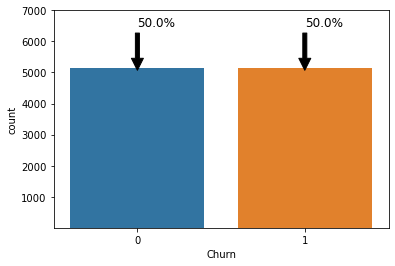

In [105]:
class0, class1 = y_sm.value_counts()
percent_minor = (class0 / (class0 + class1))*100
percent_major = (class1 / (class0 + class1))*100

ax = sns.countplot(x=y_sm)

ax.annotate(
    f'{round(percent_minor, 2)}%', 
    xy=(1, 5000), 
    xytext=(1, 6500), 
    fontsize=12,
    arrowprops=dict(facecolor='black', shrink=0.05)
)

ax.annotate(
    f'{round(percent_major, 2)}%', 
    xy=(0, 5000), 
    xytext=(0, 6500), 
    fontsize=12,
    arrowprops=dict(facecolor='black', shrink=0.05)
)
plt.yticks([1000, 2000, 3000, 4000, 5000, 6000, 7000])
plt.show()

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sm,
    y_sm,
    test_size=.25,
    random_state=102
)

In [114]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

In [120]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_validate

random_ = 15

model_params = {
    'svm': {
        'model': SVC(random_state=random_),
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=random_),
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=random_)
    },
    'DecisionTreeClassifier': {
        'model': DecisionTreeClassifier(random_state=random_),
    },
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
    },
    'MultinomialNB': {
        'model': MultinomialNB(),
    },
    'GaussianNB': {
        'model': GaussianNB(),
    }
}

def tuning_models(x, y, models, max_shuffle=10, asframe=False):
    estimated_model = {}
    for model_name, model in models.items():
        
        rs = ShuffleSplit(n_splits=max_shuffle, test_size=.25)
        cv_results = cross_validate(
            model['model'], x, y, cv=rs, scoring='accuracy'
        )
        
        estimated_model[model_name]= cv_results['test_score']
    df = pd.DataFrame(estimated_model, index=[f'accuracy : {i}' for i in range(max_shuffle)])    
    
    
    if asframe:
        return df
    else:
        scoring = {key:np.mean(val) for key, val in estimated_model.items()}
        return {max(scoring): scoring[max(scoring)]}
    
scoring_data = tuning_models(X_train, y_train, model_params, asframe=True)

In [122]:
for col in scoring_data.columns:
    print(f'{col}: {scoring_data[col].mean()}')

svm: 0.795440414507772
LogisticRegression: 0.802538860103627
RandomForestClassifier: 0.8317616580310881
DecisionTreeClassifier: 0.7651295336787565
KNeighborsClassifier: 0.7884455958549222
MultinomialNB: 0.773264248704663
GaussianNB: 0.7705181347150258


In [125]:
scores = []
clf = GridSearchCV(
    RandomForestClassifier(),
    {   
        'n_estimators': [300, 350, 400],
        'max_depth': [3,4,5,7,10],
        'criterion':['gini'],
        'min_samples_leaf' : [1, 3, 5],
        'max_features':['auto'],
        'min_samples_split': [5, 10, 15],
        'max_leaf_nodes':[3,5]
    },
    cv=5,
    return_train_score=False
)
clf.fit(X_train, y_train)
scores.append({
    'model': 'RandomForestClassifier',
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
})

In [129]:
cv_df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
cv_df.loc[0,'best_params']

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'auto',
 'max_leaf_nodes': 5,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 300}

In [159]:
from sklearn.metrics import accuracy_score
r_state = np.arange(1, 50)
get_best_random = {}

for i in r_state:
    model = RandomForestClassifier(random_state=i)
    model.fit(X_train, y_train)
    y_predicted = model.predict(X_test)
    get_best_random[i] = accuracy_score(y_test, y_predicted)

In [161]:
max_idx = max(get_best_random, key=get_best_random.get) 
{max_idx: get_best_random[max_idx]}

{39: 0.8457653457653458}

In [162]:
model = RandomForestClassifier(random_state=39)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=39)

In [163]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1306
           1       0.83      0.87      0.85      1268

    accuracy                           0.85      2574
   macro avg       0.85      0.85      0.85      2574
weighted avg       0.85      0.85      0.85      2574

